In [1]:
import sys
import numpy as np
import anndata as ad
from markdown_it.common.html_re import cdata

sys.path.insert(0, '..')

import src as scit
import anndata as ad

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = ad.read_h5ad('private/data/clean_method/mutant.h5ad')

In [3]:
# Imputation
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=4) # X_glue is also good
scit.gr.knn_impute(adata, ['acet', 'meth'], obsp_key='connectivities')

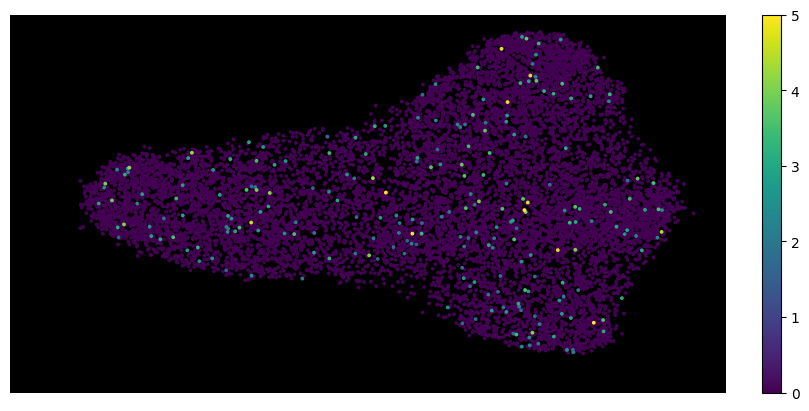

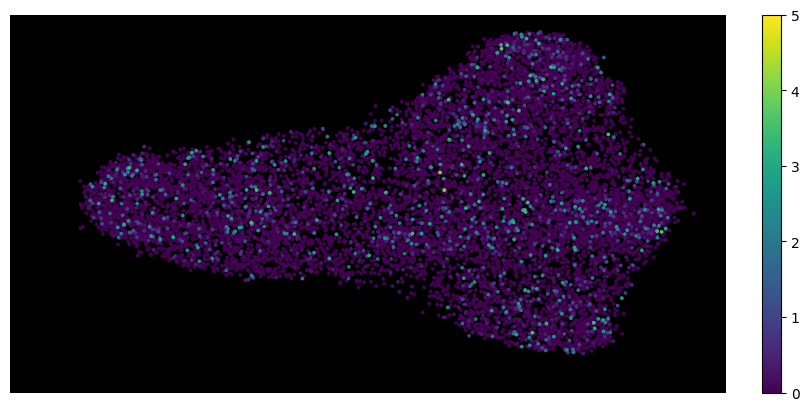

In [4]:
# Check result
pre_imp_acet = scit.tl.make_layer_config('acet', log_transform=True, normalize_with_obs_counts=True, feature_names=adata.var_names)
imputed_acet = scit.tl.make_layer_config('imputed_acet', log_transform=True, normalize_with_obs_counts=True, feature_names=adata.var_names)

var_index = 'chr2L:10000000-10005000'
scit.set_defaults(figsize=(8,4))
scit.tl.layer_pick_features(adata, pre_imp_acet, var_index)
scit.tl.copy_to_obs(adata, pre_imp_acet)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', vminmax=(0,5), black_background=True)

scit.tl.layer_pick_features(adata, imputed_acet, var_index)
scit.tl.copy_to_obs(adata, imputed_acet)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', vminmax=(0,5), black_background=True)

In [5]:
import pickle

rna = ad.read_h5ad('../data/scglue/user/emb-rna.h5ad')
reg = scit.ld.regulatory_links('../data/scglue/user/bin.links', rna)
scit.tl.regulatory_ensure_promoter_included(reg, adata, rna)

# Get sparse adjacency matrix of regulation (n gene features x n bin features)

R = scit.tl.get_regulatory_matrix(reg, rna.var_names, adata.var_names)

Info: 73 features had promoter overlapping with at least one other feature, creating ambiguity


In [6]:
#import polars as pl
#names = pl.read_csv('private/rna_features.csv')['column_0'].to_numpy()
names = np.array(rna.var_names.to_list())

In [7]:
# Alternatively, create a regulatory matrix by linking gene to bins
# in a sparse binary csr matrix.

# import scipy.sparse as sps
# R = sps.csr_matrix( ..., dtype=np.bool_)

In [7]:
lc_meth = scit.tl.make_layer_config('meth')
lc_acet = scit.tl.make_layer_config('acet')

# Infer gene acetylation/methylation layers
scit.tl.infer_layer(adata, R, lc_acet, names, 'acet')
scit.tl.infer_layer(adata, R, lc_meth, names, 'meth')

lc_meth = scit.tl.make_layer_config('imputed_meth')
lc_acet = scit.tl.make_layer_config('imputed_acet')

# Infer gene acetylation/methylation layers
scit.tl.infer_layer(adata, R, lc_acet, names, 'acet_imp')
scit.tl.infer_layer(adata, R, lc_meth, names, 'meth_imp')

In [8]:
adata.write_h5ad('private/data/clean_method/mutant_inferred.h5ad')

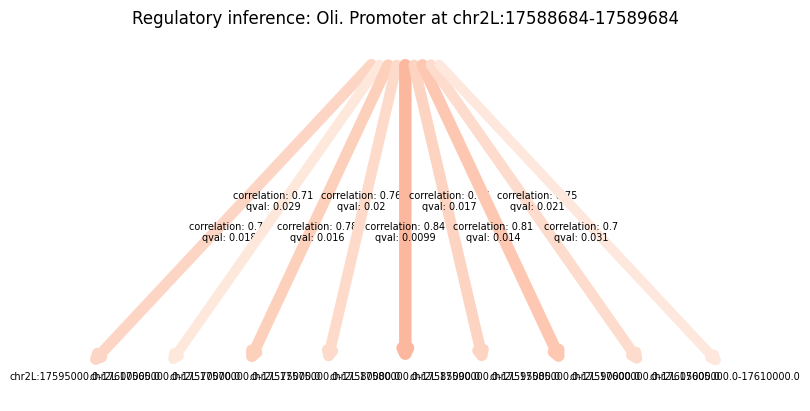

In [9]:
# Visualize Oli regulation

scit.pl.regulatory_links(reg, 'Oli')

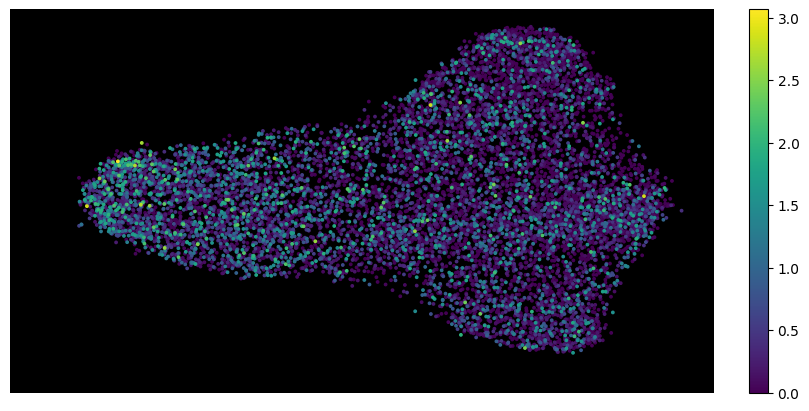

In [10]:
# The inferred data is in .obsm (since feature number is different)
acet = scit.tl.make_layer_config('acet_imp', in_obsm=True, normalize_with_obs_counts=True, log_transform=True, feature_names=names)

# Visualize Oli gene acetylation
# The layer to infer Oli regulation is binary,
# however, the inferred layer divides signal by total number of
# involved bins (Oli regulation is spread over 9 bins)
scit.tl.layer_pick_features(adata, acet, 'Oli')
scit.tl.copy_to_obs(adata, acet)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', black_background=True)

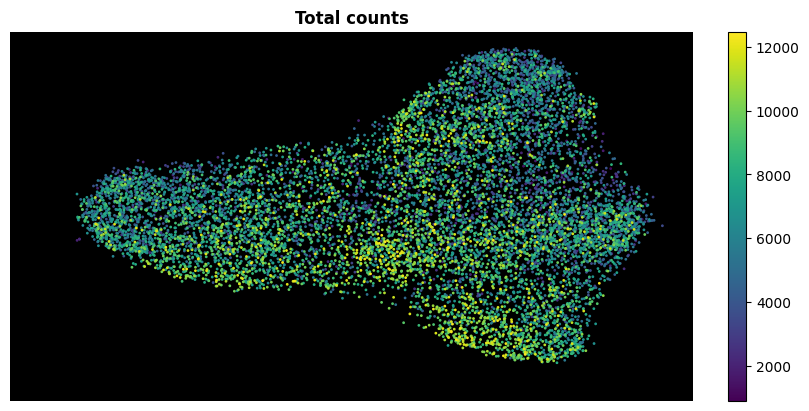

In [11]:
lc_acet_full = scit.tl.make_layer_config(
    'acet_imp', in_obsm=True, feature_active_threshold=0
)
X = lc_acet_full.transform(adata, binarize=True)
adata.obs['copied_data'] = X.sum(axis=1).A1
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', size=1, black_background=True, title='Total counts')